# Project 3: Ames Housing Price Analysis

## What Drives Housing Prices?  
### A Predictive Analysis of Residential Property Values

**Student:** Irfan Okay  
**Course:** DSC Project 3 - Milestone 3 (Python Scripts)

---



# Python Analysis

The next sections load the data, clean it, explore it visually, build models, and evaluate results.

In [5]:
# Import the main libraries needed for data handling, visualization, modeling, and evaluation.

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tools for splitting data and building preprocessing/modeling pipelines.
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Tools for handling missing values, scaling numeric variables, and encoding categorical variables.
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Regression models used for comparison.
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Metrics used to evaluate model performance.
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Optional tool for examining feature importance.
from sklearn.inspection import permutation_importance

# Make pandas output easier to read.
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

## Data Loading

This cell tries three loading options:

1. `train.csv` from the Kaggle House Prices dataset
2. `AmesHousing.csv` from a local download
3. OpenML `house_prices` dataset

If the first two local files do not exist, the notebook attempts to fetch the data from OpenML.

In [7]:
def load_ames_data():
    # First, try the Kaggle file if it is already saved in the notebook folder.
    if os.path.exists("train.csv"):
        df_local = pd.read_csv("train.csv")
        source = "Local Kaggle file: train.csv"
        return df_local, source

    # If the Kaggle file is not available, try the full Ames Housing file.
    if os.path.exists("AmesHousing.csv"):
        df_local = pd.read_csv("AmesHousing.csv")
        source = "Local Ames file: AmesHousing.csv"
        return df_local, source

    # As a backup, try to load the dataset directly from OpenML.
    try:
        from sklearn.datasets import fetch_openml
        data = fetch_openml(name="house_prices", as_frame=True)
        df_openml = data.frame.copy()
        source = "OpenML: house_prices"
        return df_openml, source

    # If none of the options work, give a clear message about what is missing.
    except Exception as e:
        raise FileNotFoundError(
            "Could not load the dataset. Place train.csv or AmesHousing.csv in the same folder as this notebook, "
            "or run the notebook in an environment with internet access so it can fetch OpenML data."
        ) from e


# Load the data and keep track of where it came from.
df, data_source = load_ames_data()

# Confirm that the dataset loaded correctly.
print("Data source:", data_source)
print("Shape:", df.shape)

# Preview the first few rows.
df.head()

Data source: OpenML: house_prices
Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000


## Initial Data Inspection

This section checks the size of the data, the column names, the data types, and whether the target variable `SalePrice` is available.

In [9]:
print("Rows and columns:", df.shape)
print("\nFirst 20 columns:")
print(df.columns[:20].tolist())

print("\nTarget available?", "SalePrice" in df.columns)

df.info()

Rows and columns: (1460, 81)

First 20 columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt']

Target available? True
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   

In [10]:
# Basic summary statistics for numerical columns
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## Missing Value Analysis

Missing values are common in housing data. In this dataset, a missing garage or basement value may sometimes mean the house does not have that feature. For a general modeling pipeline, this notebook uses median imputation for numeric variables and a constant value for categorical variables.

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_table[missing_table["missing_count"] > 0].head(25)

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageYrBlt,81,5.55
GarageCond,81,5.55
GarageType,81,5.55
GarageFinish,81,5.55


# Exploratory Data Analysis

The goal of EDA is to understand the target variable and the main predictors before modeling.

## Figure 1: Distribution of Sale Prices

This histogram shows whether housing prices are normally distributed or skewed. Housing prices are often right-skewed because a small number of expensive houses can stretch the upper end of the distribution.

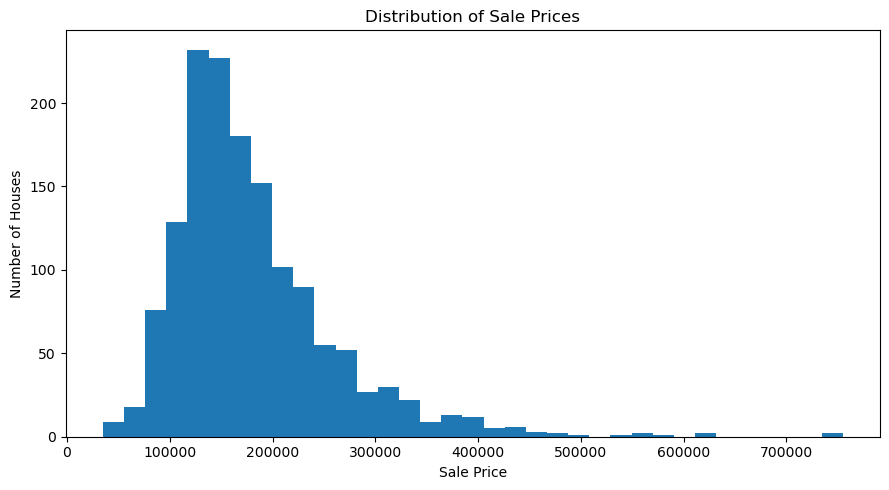

In [15]:
# The following is a stardard setup for graphing in python:
plt.figure(figsize=(9, 5))
plt.hist(df["SalePrice"].dropna(), bins=35)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

## Figure 2: Log Distribution of Sale Prices

Because sale prices are often right-skewed, the logarithm of sale price can sometimes make modeling easier. This project evaluates models on the original dollar scale for easier interpretation, but the log transformation is shown for understanding the distribution.

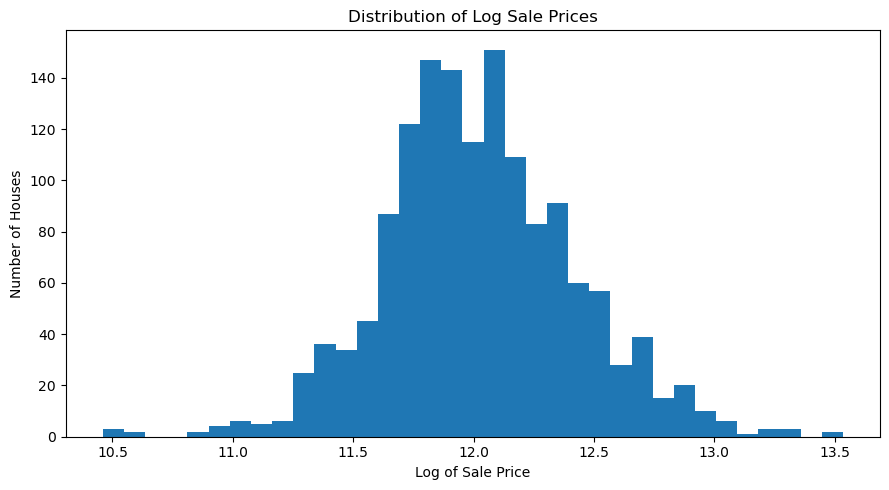

In [17]:
plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["SalePrice"].dropna()), bins=35)
plt.title("Distribution of Log Sale Prices")
plt.xlabel("Log of Sale Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

## Figure 3: Living Area vs. Sale Price

This scatterplot examines whether larger homes tend to sell for higher prices. A positive relationship is expected.

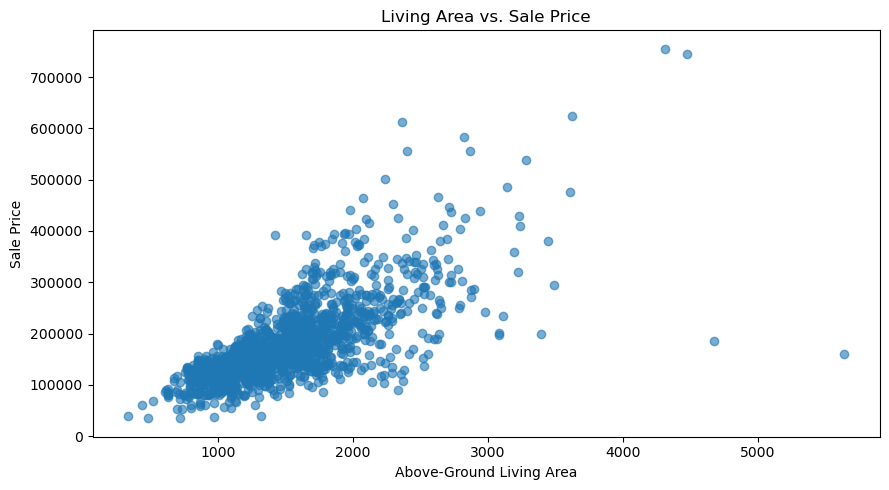

In [19]:
if "GrLivArea" in df.columns:
    plt.figure(figsize=(9, 5))
    plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.6)
    plt.title("Living Area vs. Sale Price")
    plt.xlabel("Above-Ground Living Area")
    plt.ylabel("Sale Price")
    plt.tight_layout()
    plt.show()
else:
    print("GrLivArea was not found in the dataset.")

## Figure 4: Sale Price by Neighborhood

This boxplot shows whether sale prices differ across neighborhoods. Neighborhood often captures location-based differences in demand, amenities, school access, convenience, and buyer perceptions.

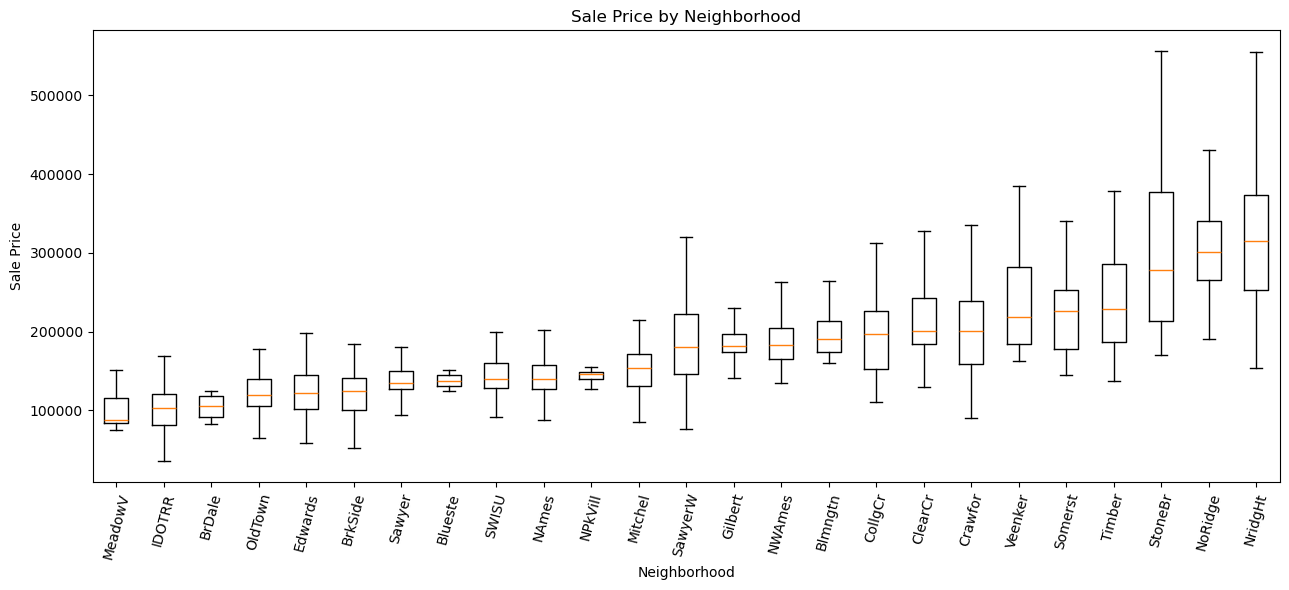

In [21]:
if "Neighborhood" in df.columns:
    # Order neighborhoods by median sale price for readability
    order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index
    data_to_plot = [df.loc[df["Neighborhood"] == n, "SalePrice"].dropna() for n in order]

    plt.figure(figsize=(13, 6))
    plt.boxplot(data_to_plot, labels=order, vert=True, showfliers=False)
    plt.title("Sale Price by Neighborhood")
    plt.xlabel("Neighborhood")
    plt.ylabel("Sale Price")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()
else:
    print("Neighborhood was not found in the dataset.")

## Figure 5: Correlation With Sale Price

This table and bar chart show which numerical variables have the strongest correlation with sale price. Correlation does not prove causation, but it helps identify useful predictors.

In [23]:
numeric_df = df.select_dtypes(include=[np.number]).copy()

corr_with_price = numeric_df.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
top_corr = corr_with_price.head(15)

pd.DataFrame({
    "feature": top_corr.index,
    "correlation_with_sale_price": top_corr.values
})

,feature,correlation_with_sale_price
0,OverallQual,0.790982
1,GrLivArea,0.708624
2,GarageCars,0.640409
3,GarageArea,0.623431
4,TotalBsmtSF,0.613581
5,1stFlrSF,0.605852
6,FullBath,0.560664
7,TotRmsAbvGrd,0.533723
8,YearBuilt,0.522897
9,YearRemodAdd,0.507101


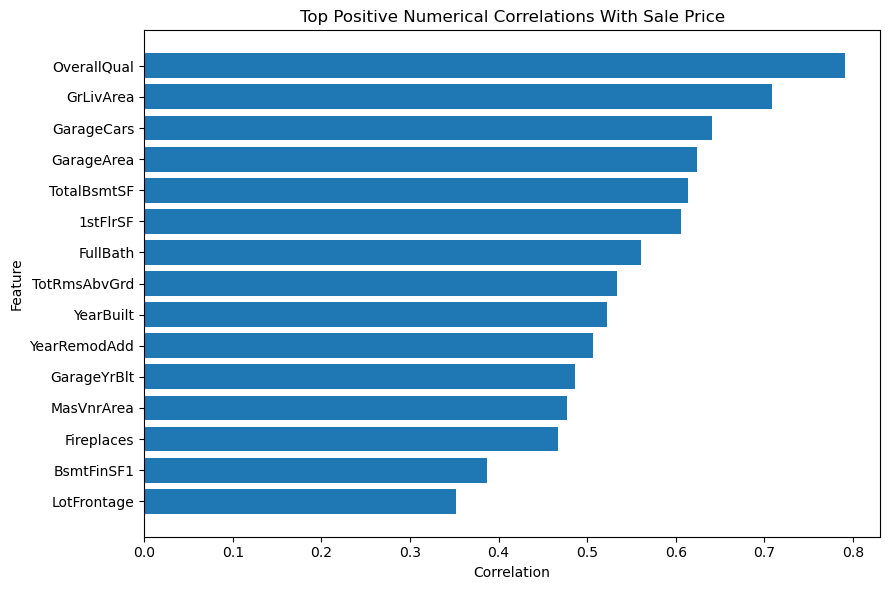

In [24]:
plt.figure(figsize=(9, 6))
plt.barh(top_corr.sort_values().index, top_corr.sort_values().values)
plt.title("Top Positive Numerical Correlations With Sale Price")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Figure 6: Correlation Heatmap for Selected Variables

This chart focuses on the variables that are expected to matter most for housing prices.

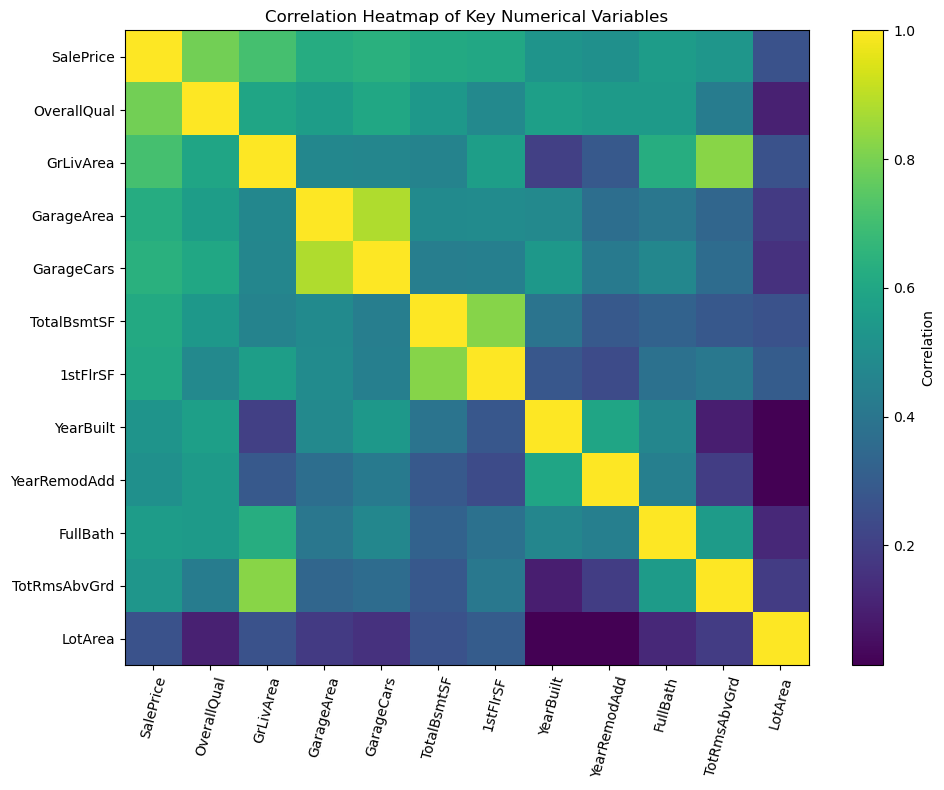

,SalePrice,OverallQual,GrLivArea,GarageArea,GarageCars,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,FullBath,TotRmsAbvGrd,LotArea
SalePrice,1.000000,0.790982,0.708624,0.623431,0.640409,0.613581,0.605852,0.522897,0.507101,0.560664,0.533723,0.263843
OverallQual,0.790982,1.000000,0.593007,0.562022,0.600671,0.537808,0.476224,0.572323,0.550684,0.550600,0.427452,0.105806
GrLivArea,0.708624,0.593007,1.000000,0.468997,0.467247,0.454868,0.566024,0.199010,0.287389,0.630012,0.825489,0.263116
GarageArea,0.623431,0.562022,0.468997,1.000000,0.882475,0.486665,0.489782,0.478954,0.371600,0.405656,0.337822,0.180403
GarageCars,0.640409,0.600671,0.467247,0.882475,1.000000,0.434585,0.439317,0.537850,0.420622,0.469672,0.362289,0.154871
TotalBsmtSF,0.613581,0.537808,0.454868,0.486665,0.434585,1.000000,0.819530,0.391452,0.291066,0.323722,0.285573,0.260833
1stFlrSF,0.605852,0.476224,0.566024,0.489782,0.439317,0.819530,1.000000,0.281986,0.240379,0.380637,0.409516,0.299475
YearBuilt,0.522897,0.572323,0.199010,0.478954,0.537850,0.391452,0.281986,1.000000,0.592855,0.468271,0.095589,0.014228
YearRemodAdd,0.507101,0.550684,0.287389,0.371600,0.420622,0.291066,0.240379,0.592855,1.000000,0.439046,0.191740,0.013788
FullBath,0.560664,0.550600,0.630012,0.405656,0.469672,0.323722,0.380637,0.468271,0.439046,1.000000,0.554784,0.126031


In [26]:
selected_for_heatmap = [
    "SalePrice", "OverallQual", "GrLivArea", "GarageArea", "GarageCars",
    "TotalBsmtSF", "1stFlrSF", "YearBuilt", "YearRemodAdd",
    "FullBath", "TotRmsAbvGrd", "LotArea"
]

available_heatmap_cols = [col for col in selected_for_heatmap if col in df.columns]

corr_matrix = df[available_heatmap_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(available_heatmap_cols)), available_heatmap_cols, rotation=75)
plt.yticks(range(len(available_heatmap_cols)), available_heatmap_cols)
plt.title("Correlation Heatmap of Key Numerical Variables")
plt.tight_layout()
plt.show()

corr_matrix

# Feature Preparation

The project uses a practical mix of numeric and categorical predictors. The model pipeline automatically imputes missing values and encodes categorical variables.

In [28]:
# Remove columns that should not be used directly as predictors
drop_candidates = ["SalePrice", "Id", "PID"]
target = "SalePrice"

if target not in df.columns:
    raise ValueError("The target variable SalePrice was not found.")

X = df.drop(columns=[col for col in drop_candidates if col in df.columns])
y = df[target].copy()

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))
print("Sample numeric features:", numeric_features[:10])
print("Sample categorical features:", categorical_features[:10])

Number of numeric features: 36
Number of categorical features: 43
Sample numeric features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2']
Sample categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


In [29]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train/Test Split

The data is split into training and testing sets. The models learn from the training set and are evaluated on the test set.

In [31]:
# Split the data so the models can learn from one part and be tested on unseen data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1168
Testing rows: 292


# Modeling

The project compares three models:

1. Linear Regression
2. Ridge Regression
3. Random Forest Regression

Linear regression is easy to interpret. Ridge regression is a regularized linear model that can handle many correlated predictors better. Random forest regression is a nonlinear machine learning model that can capture interactions between variables.

In [33]:
# Train several models, evaluate each one on the test data, and store the results for comparison.

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2,
        n_jobs=-1
    )
}

results = []

fitted_models = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)

    r2 = r2_score(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions, squared=False)
    mae = mean_absolute_error(y_test, predictions)

    results.append({
        "model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    fitted_models[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,model,R2,RMSE,MAE
2,Random Forest,0.890881,28930.638200,17465.272524
1,Ridge Regression,0.878446,30534.613522,19177.389829
0,Linear Regression,0.443492,65334.525252,21106.756340


## Figure 7: Model Performance Comparison

This chart compares models using RMSE. Lower RMSE means the model has smaller prediction errors on average, with larger errors receiving more weight.

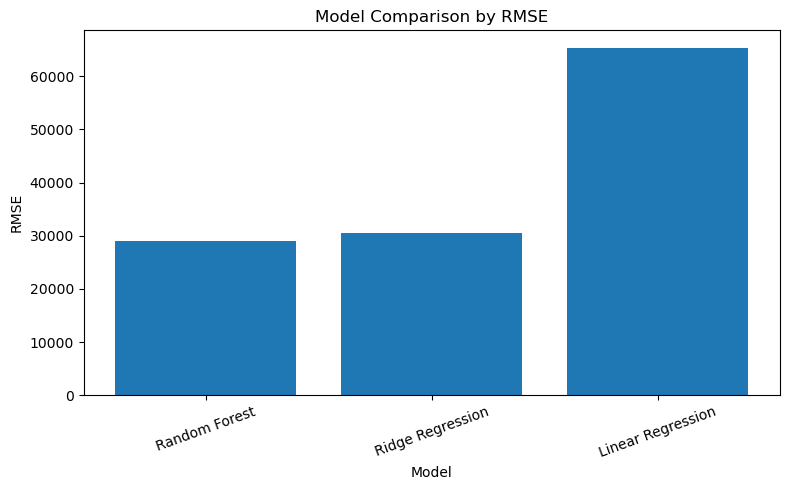

In [35]:
# Visualize the RMSE values so the models can be compared more easily.

plt.figure(figsize=(8, 5))
plt.bar(results_df["model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Figure 8: Actual vs. Predicted Sale Prices

This chart compares predicted prices with actual sale prices for the best-performing model. A strong model should have points close to the diagonal line.

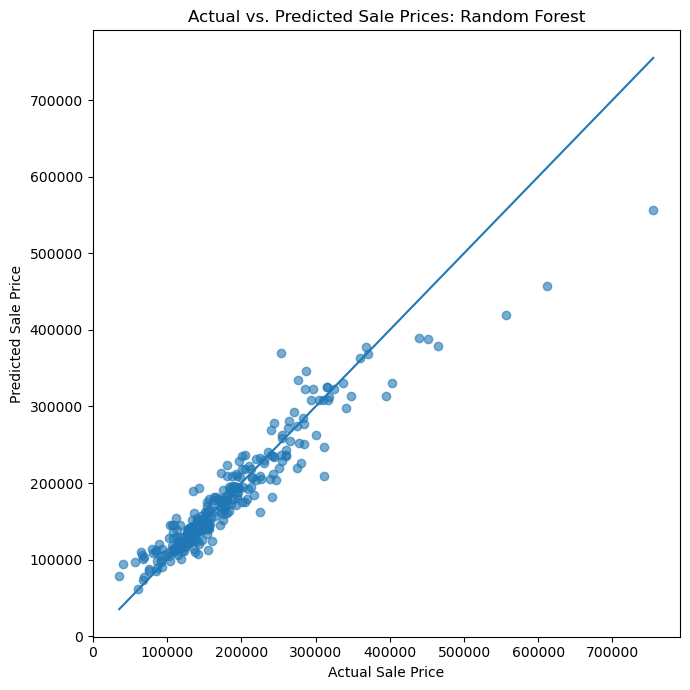

Best model: Random Forest


In [37]:
# Use the best-performing model to visualize how close its predictions are to the actual sale prices.

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

best_predictions = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.6)
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.title(f"Actual vs. Predicted Sale Prices: {best_model_name}")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.tight_layout()
plt.show()

print("Best model:", best_model_name)

# Feature Importance

For the random forest model, feature importance can help identify which variables are most useful for prediction. Because categorical variables are one-hot encoded, the feature names include encoded neighborhood and quality categories when applicable.

In [39]:
# Extract and display the most important variables from the Random Forest model.

rf_pipe = fitted_models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]

# Get transformed feature names
preprocessor_fitted = rf_pipe.named_steps["preprocessor"]

feature_names = []

# Numeric feature names
feature_names.extend(numeric_features)

# Categorical one-hot names
if len(categorical_features) > 0:
    ohe = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_feature_names)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance_df.head(20)

,feature,importance
3,OverallQual,0.565409
15,GrLivArea,0.122944
11,TotalBsmtSF,0.033512
13,2ndFlrSF,0.032057
8,BsmtFinSF1,0.028854
12,1stFlrSF,0.026203
2,LotArea,0.018019
26,GarageArea,0.015720
25,GarageCars,0.014210
5,YearBuilt,0.012367


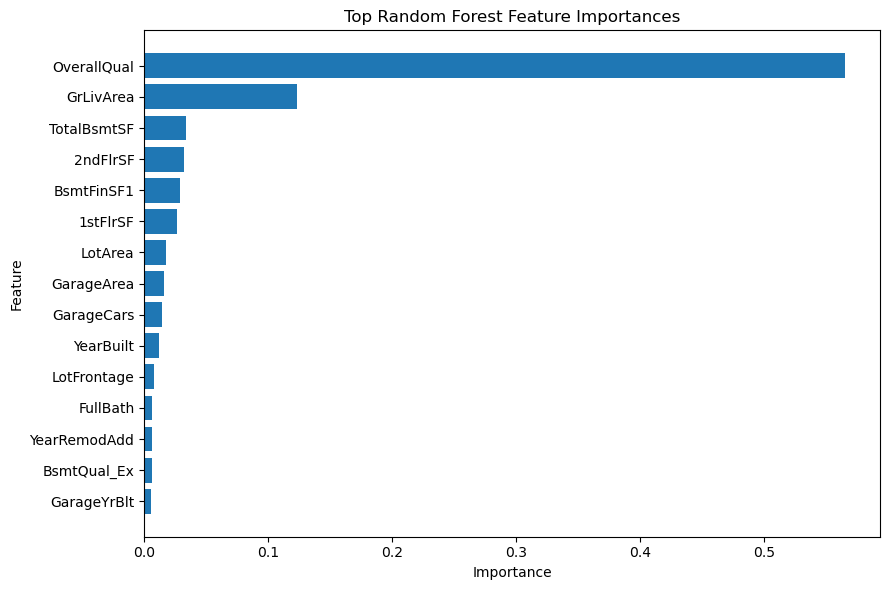

In [40]:
# Show the most important Random Forest predictors in a simple horizontal bar chart.
top_importance = importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()